# Students performance in exams
#### Marks secured by the students in college

## Aim
#### To understand the influence of various factors like economic, personal and social on the students performance 

## Inferences would be : 
#### 1. How to imporve the students performance in each test ?
#### 2. What are the major factors influencing the test scores ?
#### 3. Effectiveness of test preparation course?
#### 4. Other inferences 

#### Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Let us initialize the required values ( we will use them later in the program )
#### we will set the minimum marks to 40 to pass in a exam

In [2]:
passmark = 40

#### Let us read the data from the csv file

In [3]:
df = pd.read_csv("../input/StudentsPerformance.csv")

#### We will print top few rows to understand about the various data columns

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Size of data frame

In [5]:
print (df.shape)

(1000, 8)


#### Let us understand about the basic information of the data, like min, max, mean and standard deviation etc.

In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Let us check for any missing values

In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### As seen above, there are no missing ( null ) values in this dataframe but in real scenarios we need work on dataset with a lot of missing values  

####  Let us explore the Math Score first

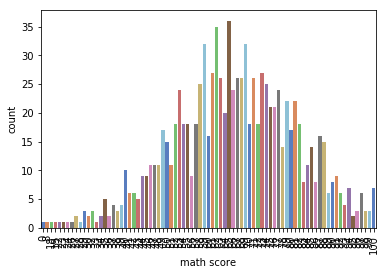

In [8]:
p = sns.countplot(x="math score", data = df, palette="muted")
_ = plt.setp(p.get_xticklabels(), rotation=90) 

#### How many students passed in Math exam ?

In [9]:
df['Math_PassStatus'] = np.where(df['math score']<passmark, 'F', 'P')
df.Math_PassStatus.value_counts()

P    960
F     40
Name: Math_PassStatus, dtype: int64

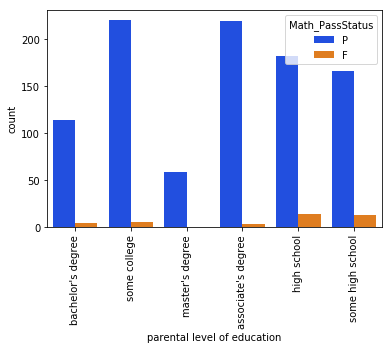

In [10]:
p = sns.countplot(x='parental level of education', data = df, hue='Math_PassStatus', palette='bright')
_ = plt.setp(p.get_xticklabels(), rotation=90) 

#### Let us explore the Reading score

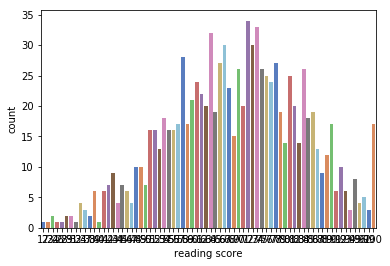

In [11]:
sns.countplot(x="reading score", data = df, palette="muted")
plt.show()

#### How many studends passed in reading ?

In [12]:
df['Reading_PassStatus'] = np.where(df['reading score']<passmark, 'F', 'P')
df.Reading_PassStatus.value_counts()

P    974
F     26
Name: Reading_PassStatus, dtype: int64

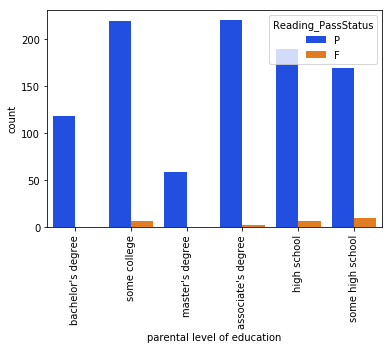

In [13]:
p = sns.countplot(x='parental level of education', data = df, hue='Reading_PassStatus', palette='bright')
_ = plt.setp(p.get_xticklabels(), rotation=90) 

#### Let us explore writing score

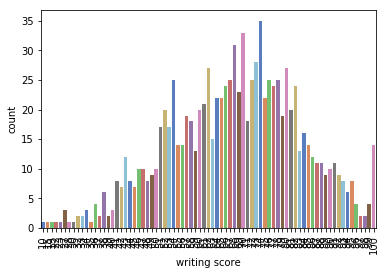

In [14]:
p = sns.countplot(x="writing score", data = df, palette="muted")
_ = plt.setp(p.get_xticklabels(), rotation=90) 

#### How many students passed writing ?

In [15]:
df['Writing_PassStatus'] = np.where(df['writing score']<passmark, 'F', 'P')
df.Writing_PassStatus.value_counts()

P    968
F     32
Name: Writing_PassStatus, dtype: int64

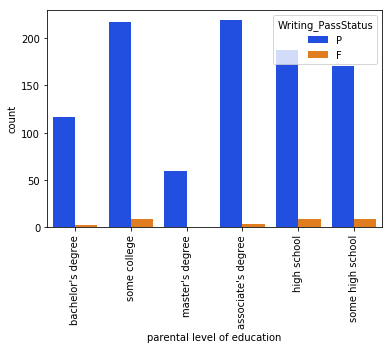

In [16]:
p = sns.countplot(x='parental level of education', data = df, hue='Writing_PassStatus', palette='bright')
_ = plt.setp(p.get_xticklabels(), rotation=90) 

In [17]:
df[['math score', 'reading score', 'writing score']].mean()

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

In [18]:
scores = df.melt(
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='subject',
    value_name='score'
)

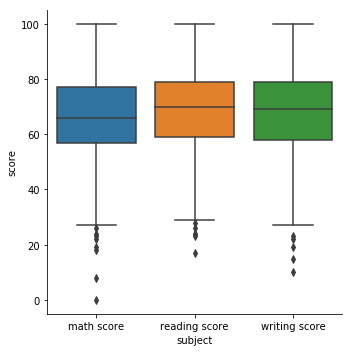

In [19]:
sns.catplot(
    x='subject',
    y='score',
    data=scores,
    kind='box'
)

#### Iet us check "How many students passed in all the subjects ?"

In [20]:
df['OverAll_PassStatus'] = df.apply(lambda x : 'F' if x['Math_PassStatus'] == 'F' or 
                                    x['Reading_PassStatus'] == 'F' or x['Writing_PassStatus'] == 'F' else 'P', axis =1)

df.OverAll_PassStatus.value_counts()

P    949
F     51
Name: OverAll_PassStatus, dtype: int64

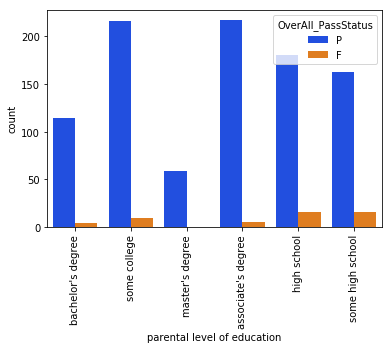

In [21]:
p = sns.countplot(x='parental level of education', data = df, hue='OverAll_PassStatus', palette='bright')
_ = plt.setp(p.get_xticklabels(), rotation=90) 

In [22]:
df['OverAll_PassNumeric'] = df['OverAll_PassStatus'].map({'P': 1, 'F': 0})

In [23]:
df[['OverAll_PassStatus', 'OverAll_PassNumeric']].head()

,OverAll_PassStatus,OverAll_PassNumeric
0,P,1
1,P,1
2,P,1
3,P,1
4,P,1


## Factors Influencing Test Scores

### Parental Level of Education

In [24]:
df.groupby('parental level of education')['OverAll_PassNumeric'].mean()

parental level of education
associate's degree    0.977477
bachelor's degree     0.966102
high school           0.918367
master's degree       1.000000
some college          0.955752
some high school      0.910615
Name: OverAll_PassNumeric, dtype: float64

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


(array([0, 1, 2, 3, 4, 5]), <a list of 6 Text xticklabel objects>)

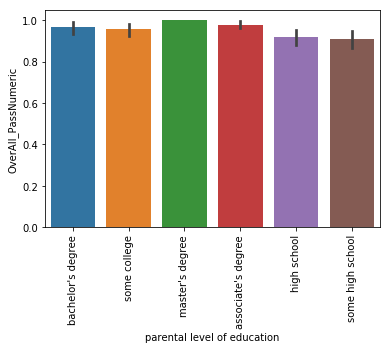

In [25]:
sns.barplot(
    x='parental level of education',
    y='OverAll_PassNumeric',
    data=df
)

plt.xticks(rotation=90)

The higher the parents' level of education, the higher the students' approval rate tends to be.

### Test Preparation Course

In [26]:
df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [27]:
scores_course = df.melt(
    id_vars='test preparation course',
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='subject',
    value_name='score'
)

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


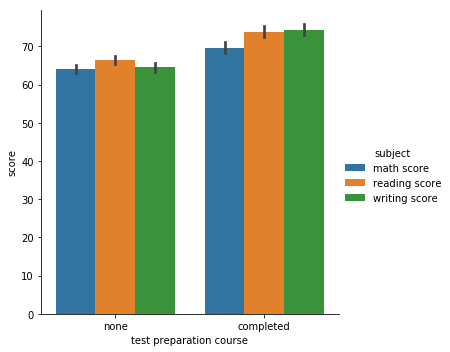

In [28]:
sns.catplot(
    x='test preparation course',
    y='score',
    hue='subject',
    data=scores_course,
    kind='bar'
)

Students who completed the test preparation course performed better in all three assessments, with higher average scores than students who did not complete the course.

### Lunch and Students Performance

In [29]:
df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


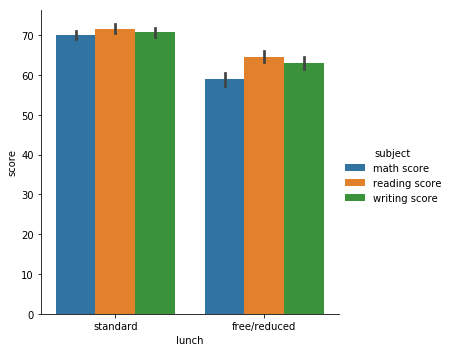

In [30]:
sns.catplot(
    x='lunch',
    y='score',
    hue='subject',
    data=df.melt(
        id_vars='lunch',
        value_vars=['math score', 'reading score', 'writing score'],
        var_name='subject',
        value_name='score'
    ),
    kind='bar'
)

Students with standard lunch tend to achieve better scores in all three tests.

### Gender and Students Performance

In [31]:
df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


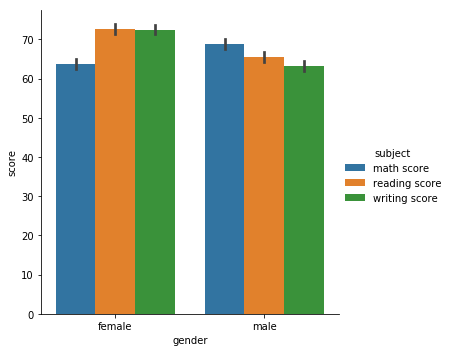

In [32]:
sns.catplot(
    x='gender',
    y='score',
    hue='subject',
    data=df.melt(
        id_vars='gender',
        value_vars=['math score', 'reading score', 'writing score'],
        var_name='subject',
        value_name='score'
    ),
    kind='bar'
)

Female students tend to perform better in reading and writing, while male students tend to perform better in mathematics.

### Race/Ethnicity

In [33]:
df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


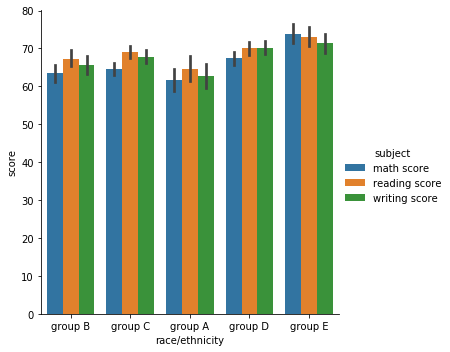

In [34]:
sns.catplot(
    x='race/ethnicity',
    y='score',
    hue='subject',
    data=df.melt(
        id_vars='race/ethnicity',
        value_vars=['math score', 'reading score', 'writing score'],
        var_name='subject',
        value_name='score'
    ),
    kind='bar'
)

Overall, students from Group E tend to have higher scores in the three tests.

Overall, several factors are associated with differences in students' test scores. Students who completed the test preparation course achieved higher average scores in all three subjects. Students with standard lunch also showed higher average scores compared to those with free/reduced lunch. Female students tended to perform better in reading and writing, while male students tended to perform better in mathematics. In addition, students from Group E had the highest average scores across the three tests, while students from Group A had lower average scores. The parental level of education was also associated with differences in overall pass rates, with higher parental education levels generally showing higher approval rates. These results suggest that students' performance is related to a combination of academic, socioeconomic, and demographic factors.

#### Find the percentage of marks

In [35]:
df['Total_Marks'] = df['math score']+df['reading score']+df['writing score']
df['Percentage'] = df['Total_Marks']/3

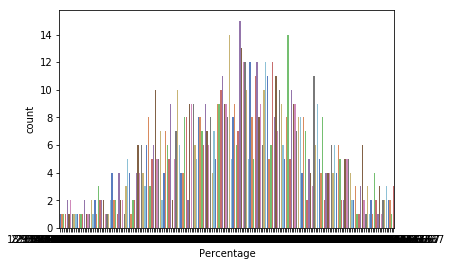

In [36]:
p = sns.countplot(x="Percentage", data = df, palette="muted")
_ = plt.setp(p.get_xticklabels(), rotation=0) 

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


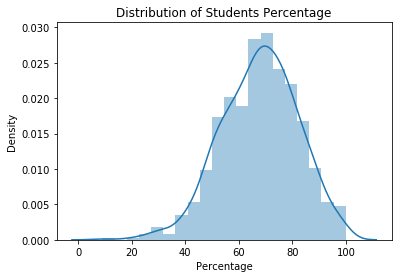

In [37]:
sns.distplot(df['Percentage'], bins=20)
plt.xlabel('Percentage')
plt.ylabel('Density')
plt.title('Distribution of Students Percentage')
plt.show()

#### Let us assign the grades

### Grading 
####    above 80 = A Grade
####      70 to 80 = B Grade
####      60 to 70 = C Grade
####      50 to 60 = D Grade
####      40 to 50 = E Grade
####    below 40 = F Grade  ( means Fail )


In [38]:
def GetGrade(Percentage, OverAll_PassStatus):
    if ( OverAll_PassStatus == 'F'):
        return 'F'    
    if ( Percentage >= 80 ):
        return 'A'
    if ( Percentage >= 70):
        return 'B'
    if ( Percentage >= 60):
        return 'C'
    if ( Percentage >= 50):
        return 'D'
    if ( Percentage >= 40):
        return 'E'
    else: 
        return 'F'

df['Grade'] = df.apply(lambda x : GetGrade(x['Percentage'], x['OverAll_PassStatus']), axis=1)

df.Grade.value_counts()

B    261
C    256
A    198
D    178
E     56
F     51
Name: Grade, dtype: int64

#### we will plot the grades obtained in a order

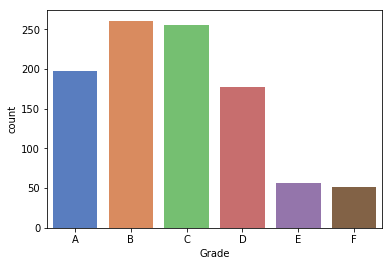

In [39]:
sns.countplot(x="Grade", data = df, order=['A','B','C','D','E','F'],  palette="muted")
plt.show()

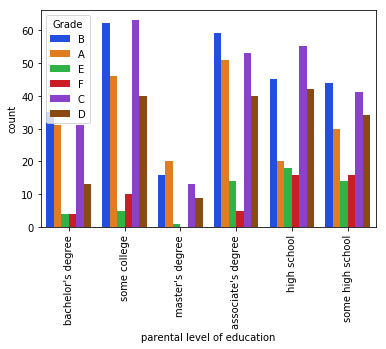

In [40]:
p = sns.countplot(x='parental level of education', data = df, hue='Grade', palette='bright')
_ = plt.setp(p.get_xticklabels(), rotation=90) 